In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd

start_date = "2000-01-01"
end_date = "2025-12-31"

sensex = yf.download("^BSESN", start=start_date, end=end_date)

prices = sensex['Close']

returns = np.log(prices / prices.shift(1)) * 100
returns = returns.dropna()
mean_return = returns.mean()
std_return = returns.std()

mean_return, std_return


/tmp/ipython-input-3003661245.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sensex = yf.download("^BSESN", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


(Ticker
 ^BSESN    0.043025
 dtype: float64,
 Ticker
 ^BSESN    1.379791
 dtype: float64)

<Figure size 800x400 with 0 Axes>

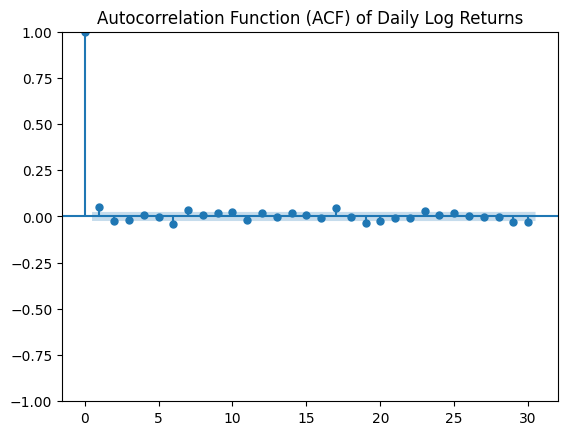

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plot_acf(returns, lags=30)
plt.title("Autocorrelation Function (ACF) of Daily Log Returns")
plt.show()


In [ ]:
from statsmodels.tsa.stattools import acf

acf_vals = acf(returns, nlags=1)
acf_lag1 = acf_vals[1]
acf_lag1


np.float64(0.05255275674186854)

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(returns, lags=[1], return_df=True)
lb_test


,lb_stat,lb_pvalue
1,17.705851,0.000026


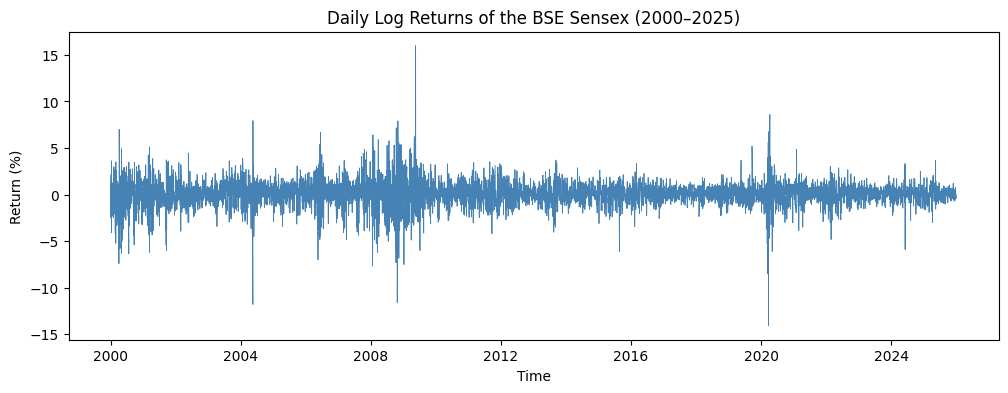

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(returns, color='steelblue', linewidth=0.6)
plt.title("Daily Log Returns of the BSE Sensex (2000–2025)")
plt.ylabel("Return (%)")
plt.xlabel("Time")
plt.show()


<Figure size 800x400 with 0 Axes>

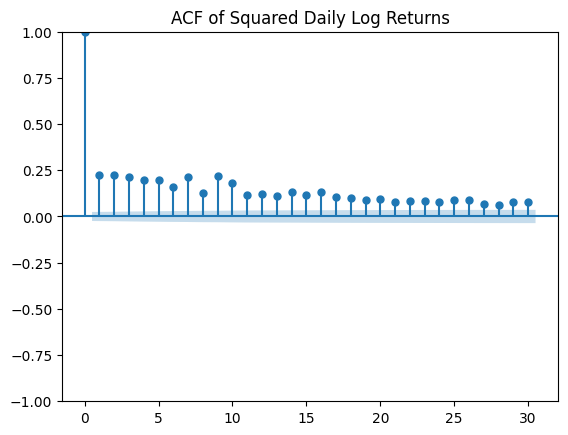

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8,4))
plot_acf(returns**2, lags=30)
plt.title("ACF of Squared Daily Log Returns")
plt.show()


In [ ]:
from scipy.stats import skew, kurtosis

skewness = skew(returns)
excess_kurtosis = kurtosis(returns, fisher=True)

skewness, excess_kurtosis


(array([-0.39798183]), array([10.04761263]))

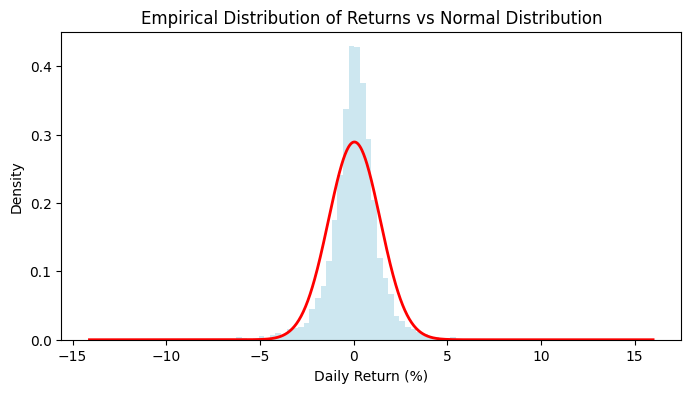

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.figure(figsize=(8,4))

# Histogram (density)
plt.hist(returns, bins=100, density=True, alpha=0.6, color='lightblue')

# Normal density with same mean and SD
x = np.linspace(returns.min(), returns.max(), 1000)
plt.plot(x, norm.pdf(x, returns.mean(), returns.std()), 'r', linewidth=2)

plt.title("Empirical Distribution of Returns vs Normal Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Density")
plt.show()


In [ ]:
# 21-day rolling volatility
rolling_vol = returns.rolling(window=21).std()
# Future volatility (next day)
future_vol = rolling_vol.shift(-1)

# Separate cases
vol_after_neg = future_vol[returns < 0]
vol_after_pos = future_vol[returns > 0]

# Compute averages
mean_vol_neg = vol_after_neg.mean()
mean_vol_pos = vol_after_pos.mean()

mean_vol_neg, mean_vol_pos


(Ticker
 ^BSESN    1.191524
 dtype: float64,
 Ticker
 ^BSESN    1.169503
 dtype: float64)